<a href="https://colab.research.google.com/github/lucasvazelle/nexialog_challlenge/blob/main/etape4_model_sans_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [424]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! pip install ace-tools

In [443]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy.stats import genpareto


In [444]:
# chemin
file_path = "/content/drive/MyDrive/nexialog/data_agrege_S3.parquet"

# Lire le fichier Parquet
data_agrege_S3 = pd.read_parquet(file_path)


In [445]:
data_agrege_S3.columns

Index(['olt_name', 'date_hour', 'code_departement', 'olt_model', 'peag_nro',
       'boucle', 'dsp', 'pop_dns', 'nb_test_dns', 'avg_dns_time',
       'std_dns_time', 'nb_test_scoring', 'avg_latence_scoring',
       'std_latence_scoring', 'avg_score_scoring', 'std_score_scoring',
       'nb_client_total', 'moment_journee', 'depts_egaux', 'meme_region',
       'missing_avg_dns_time', 'missing_std_dns_time',
       'missing_avg_latence_scoring', 'missing_std_latence_scoring',
       'missing_avg_score_scoring', 'missing_std_score_scoring', 'type_boucle',
       'type_olt_model', 'encodage_heure_sin', 'encodage_heure_cos',
       'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end'],
      dtype='object')

In [ ]:

distinct_olt_names = data_agrege_S3['olt_name'].unique()

# Afficher les valeurs distinctes
distinct_olt_names


array(['01_olt_1', '01_olt_10', '01_olt_11', ..., '95_olt_5629',
       '95_olt_5630', '95_olt_5631'], dtype=object)

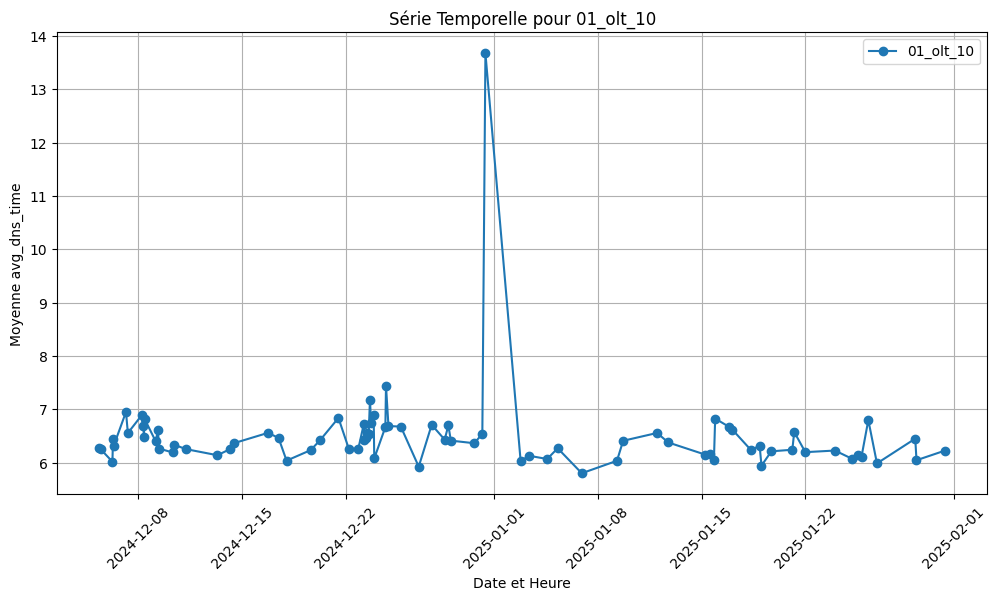

In [ ]:
olt_name = "01_olt_10"  # Remplace par le nom de l'OLT souhaité
df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name]

plt.figure(figsize=(12, 6))
plt.plot(olt_1["date_hour"], olt_1["avg_dns_time"], marker="o", linestyle="-", label=olt_a_visualiser)
plt.xlabel("Date et Heure")
plt.ylabel("Moyenne avg_dns_time")
plt.title(f"Série Temporelle pour {olt_a_visualiser}")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()


# Jump classique Andersel et Al

In [446]:
test =["avg_dns_time", "avg_latence_scoring", "avg_score_scoring"]

In [447]:
from scipy import stats
import numpy as np

def detect_jumps_andersen(df, window=50, lambda_quantile=0.9999, metrique="avg_dns_time"):
    """
    Détecte les jumps en utilisant la méthode d'Andersen, Bollerslev et Dobrev (2007).

    - window : taille de la fenêtre pour la volatilité locale.
    - lambda_quantile : seuil quantile pour la détection.
    - metrique : nom de la colonne à utiliser ('avg_dns_time', 'avg_score_scoring', etc.)

    ⚠️ Si metrique == 'avg_score_scoring', on utilise la valeur absolue des variations.
    """
    df = df.copy()
    df["log_metric"] = np.log(df[metrique])  # Log pour capturer les variations relatives
    df["diff_log"] = df["log_metric"].diff()

    # Estimation de la volatilité locale (rolling std)
    df["volatility"] = df["diff_log"].rolling(window=window, min_periods=1).std()

    # Choix du type de saut : positif pur ou valeur absolue
    if metrique == "avg_score_scoring":
        # On cherche les sauts significatifs dans les deux sens
        df["stat_jump"] = df["diff_log"].abs() / df["volatility"]
    else:
        # Sauts positifs uniquement
        df["stat_jump"] = df["diff_log"] / df["volatility"]

    # Seuil basé sur la loi normale standard
    jump_threshold = stats.norm.ppf(lambda_quantile)

    # Détection du jump selon le type
    df["is_jump"] = df["stat_jump"] > jump_threshold

    return df


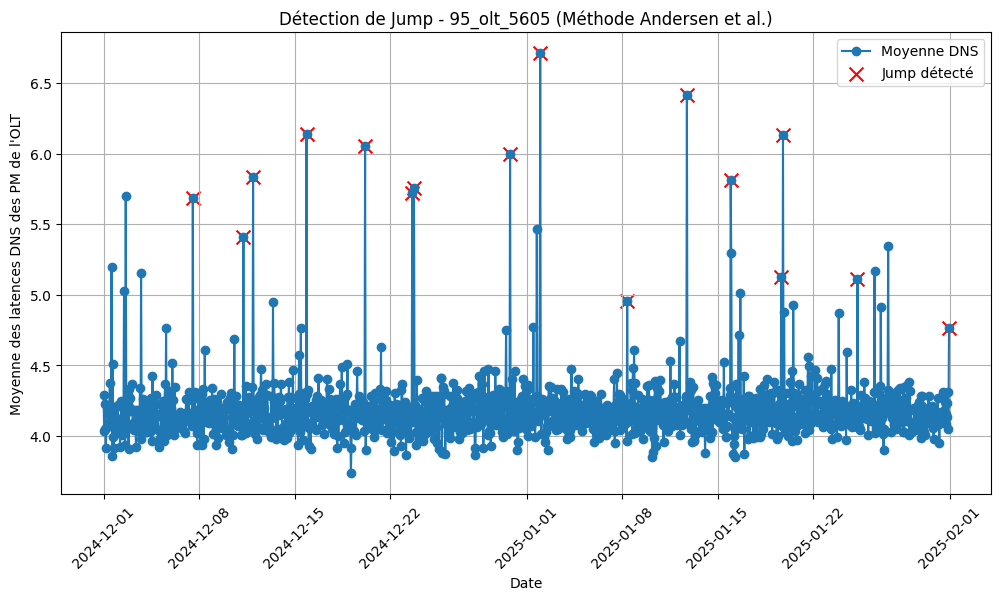

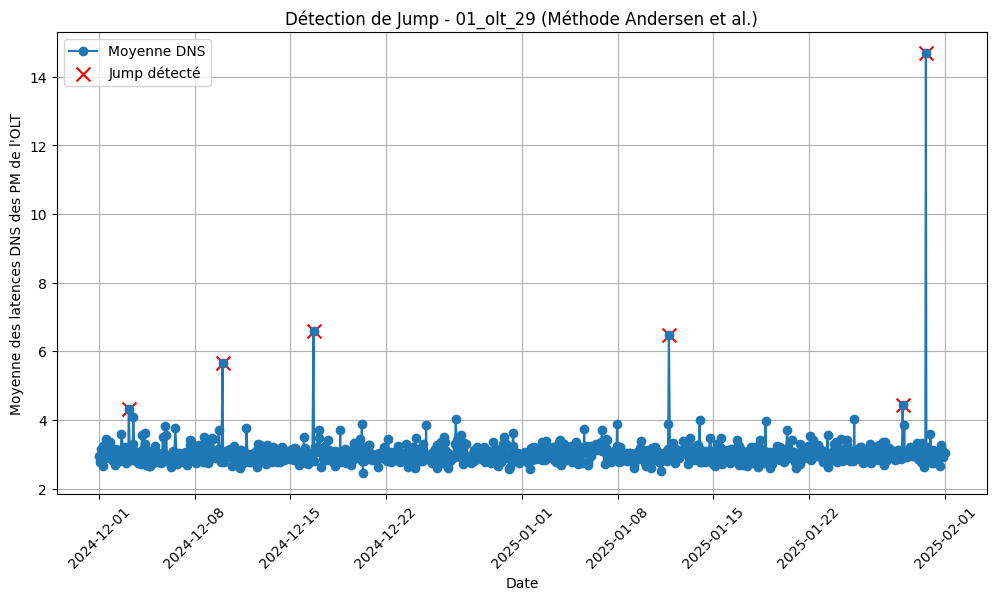

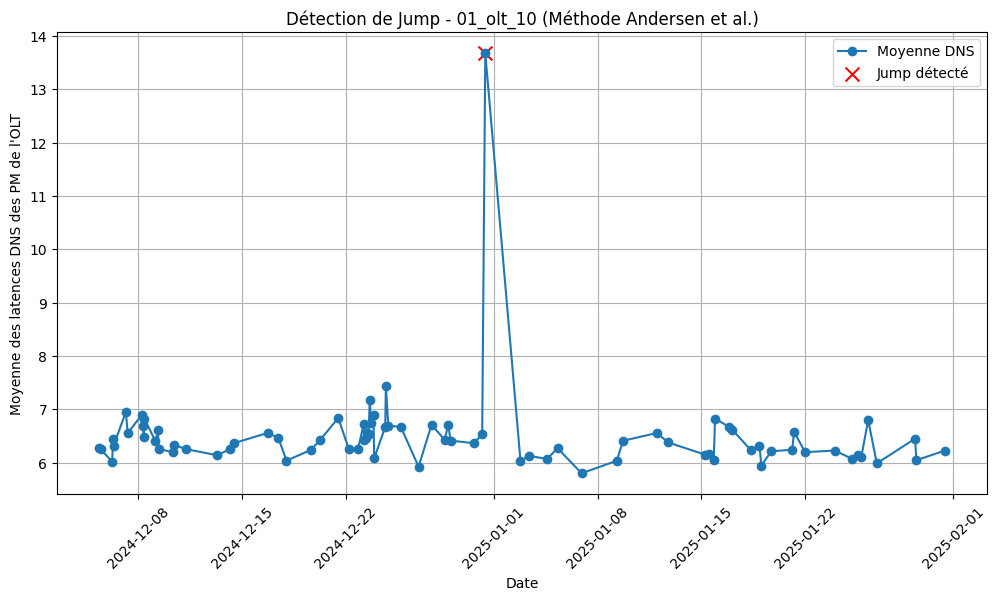

In [448]:
olt_name_list = ["95_olt_5605", "01_olt_29", "01_olt_10" ] # Remplace par le nom de l'OLT souhaité
metrique = test[0]
for olt_name in olt_name_list:
  df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name]

  # Appliquer la détection de jumps
  df_jumps = detect_jumps_andersen(df_olt, lambda_quantile=0.9999, metrique = metrique)

  # Tracer les résultats
  plt.figure(figsize=(12, 6))
  plt.plot(df_olt["date_hour"], df_olt[metrique], label="Moyenne DNS", marker="o", linestyle="-")
  plt.scatter(df_jumps[df_jumps["is_jump"]]["date_hour"], df_jumps[df_jumps["is_jump"]][metrique],
              color="red", label="Jump détecté", marker="x", s=100)
  plt.xlabel("Date")
  plt.ylabel("Moyenne des latences DNS des PM de l'OLT")
  plt.title(f"Détection de Jump - {olt_name} (Méthode Andersen et al.)")
  plt.legend()
  plt.xticks(rotation=45)
  plt.grid()
  plt.show()


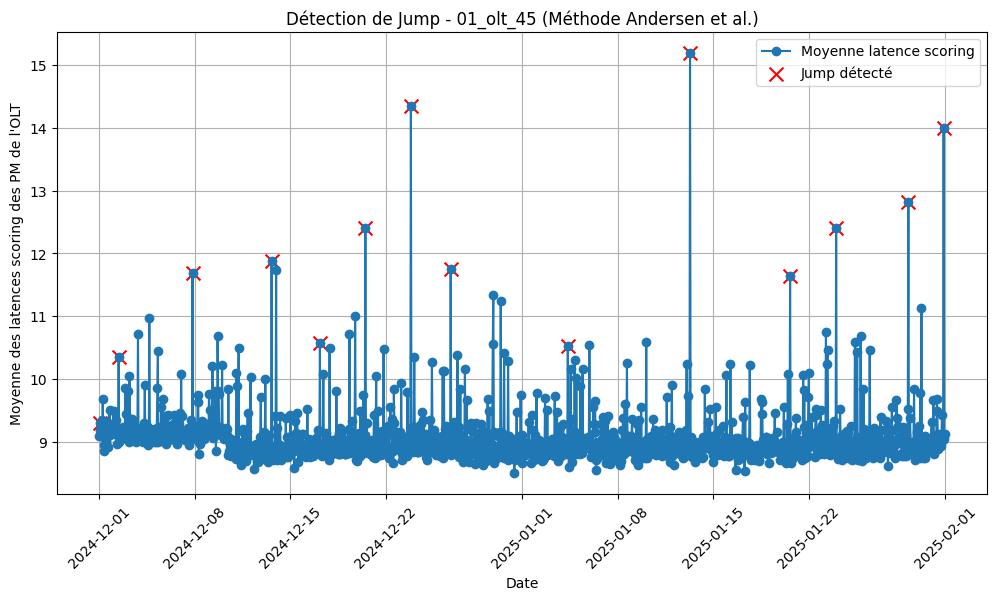

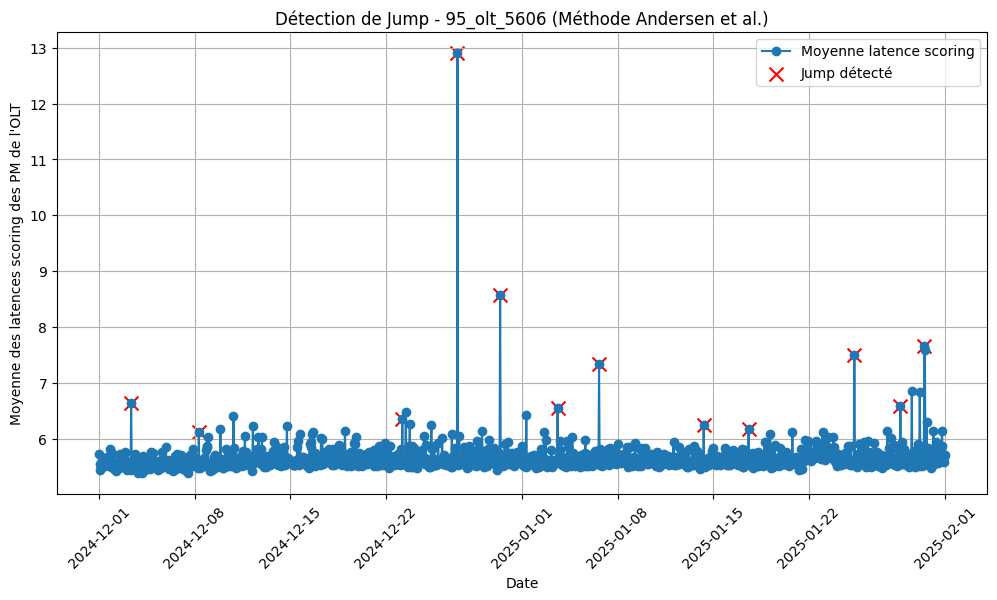

In [ ]:
olt_name_list = ["01_olt_45", "95_olt_5606" ] # Remplace par le nom de l'OLT souhaité
metrique = test[1]
for olt_name in olt_name_list:
  df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name]

  # Appliquer la détection de jumps
  df_jumps = detect_jumps_andersen(df_olt, window=50, lambda_quantile=0.9999, metrique = metrique)

  # Tracer les résultats
  plt.figure(figsize=(12, 6))
  plt.plot(df_olt["date_hour"], df_olt[metrique], label="Moyenne latence scoring", marker="o", linestyle="-")
  plt.scatter(df_jumps[df_jumps["is_jump"]]["date_hour"], df_jumps[df_jumps["is_jump"]][metrique],
              color="red", label="Jump détecté", marker="x", s=100)
  plt.xlabel("Date")
  plt.ylabel("Moyenne des latences scoring des PM de l'OLT")
  plt.title(f"Détection de Jump - {olt_name} (Méthode Andersen et al.)")
  plt.legend()
  plt.xticks(rotation=45)
  plt.grid()
  plt.show()


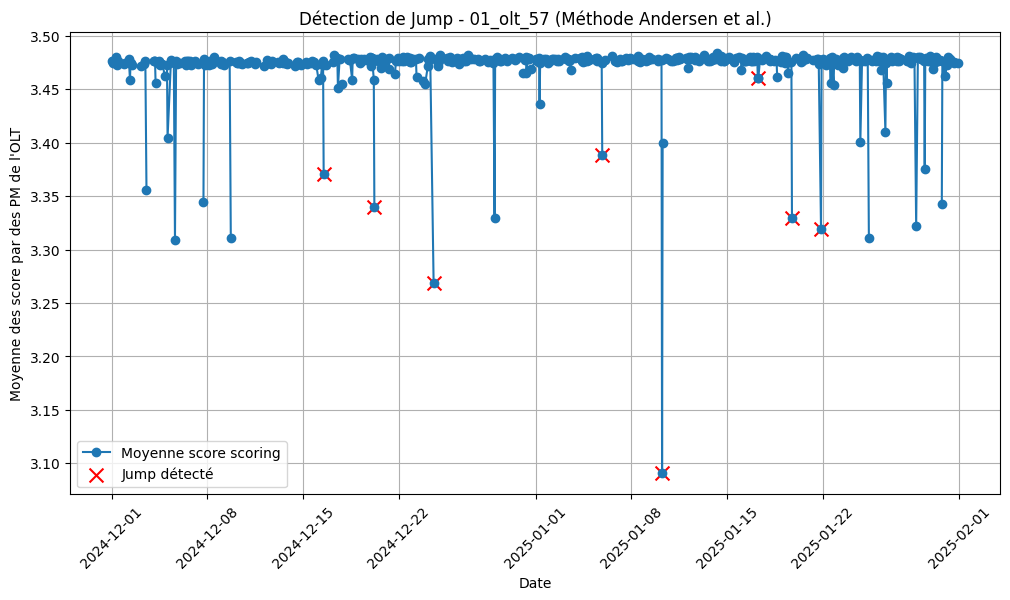

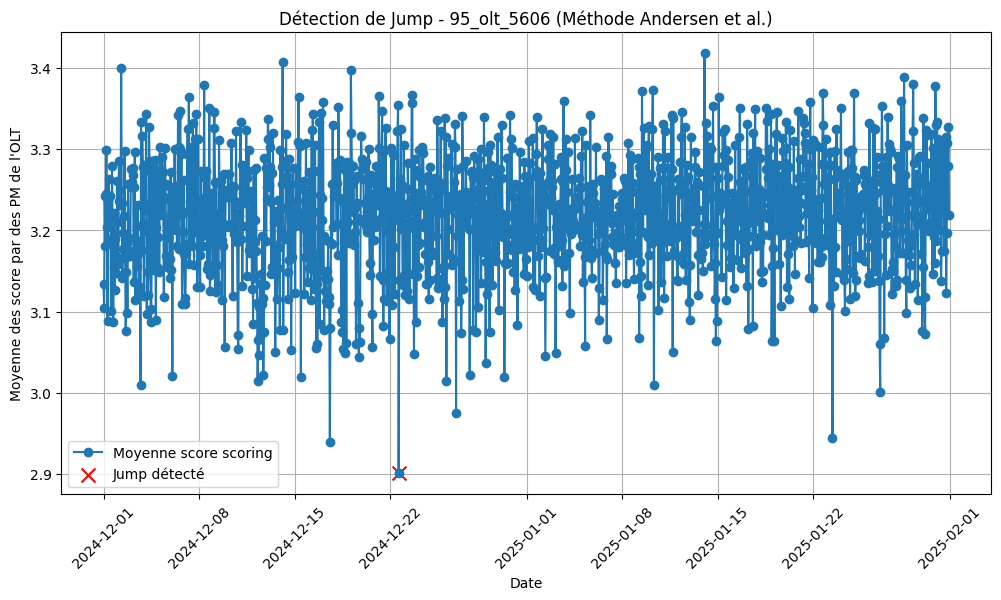

In [ ]:
olt_name_list = ["01_olt_57", "95_olt_5606" ] # Remplace par le nom de l'OLT souhaité
metrique = test[2]
for olt_name in olt_name_list:
  df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name]

  # Appliquer la détection de jumps
  df_jumps = detect_jumps_andersen(df_olt, window=50, lambda_quantile=0.9999, metrique = metrique)

  # Tracer les résultats
  plt.figure(figsize=(12, 6))
  plt.plot(df_olt["date_hour"], df_olt[metrique], label="Moyenne score scoring", marker="o", linestyle="-")
  plt.scatter(df_jumps[df_jumps["is_jump"]]["date_hour"], df_jumps[df_jumps["is_jump"]][metrique],
              color="red", label="Jump détecté", marker="x", s=100)
  plt.xlabel("Date")
  plt.ylabel("Moyenne des score par des PM de l'OLT")
  plt.title(f"Détection de Jump - {olt_name} (Méthode Andersen et al.)")
  plt.legend()
  plt.xticks(rotation=45)
  plt.grid()
  plt.show()


In [449]:
# Définir un seuil minimum d'observations par OLT
SEUIL_MIN_OBSERVATIONS = 50

# Compter les observations par OLT
olt_counts = data_agrege_S3["olt_name"].value_counts()
olt_filtrés = olt_counts[olt_counts >= SEUIL_MIN_OBSERVATIONS].index

# Afficher info
print(f"📊 Nombre d'OLTs retenus après filtrage : {len(olt_filtrés)} / {len(olt_counts)}")

# Liste des métriques à tester
tests = ["avg_dns_time", "avg_latence_scoring", "avg_score_scoring"]

# Stocker les résultats finaux
df_jumps_all = []

# Itération OLTs
for olt in olt_filtrés:
    df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt].sort_values("date_hour").copy()

    # Pour chaque métrique → appliquer la détection et stocker le résultat de jump
    for metrique in tests:
        result = detect_jumps_andersen(df_olt, window=50, lambda_quantile=0.9999, metrique=metrique)
        col_name = f"is_jump_{metrique}"
        df_olt[col_name] = result["is_jump"]  # Ajouter la colonne de jump spécifique

    df_olt["olt_name"] = olt  # Reposer la colonne OLT (si absente)
    df_jumps_all.append(df_olt)


📊 Nombre d'OLTs retenus après filtrage : 3834 / 5296


In [452]:
# Concaténer toutes les tables
df_jumps_final = pd.concat(df_jumps_all, ignore_index=True)

# Supprimer les deux premiers jours (période de chauffe pour volatilité)
start_date = df_jumps_final["date_hour"].min().normalize()
cutoff_date = start_date + pd.Timedelta(days=2)
df_jumps_final = df_jumps_final[df_jumps_final["date_hour"] > cutoff_date]


In [454]:
output_parquet_path = "/content/drive/MyDrive/nexialog/data_with_anomalies_with_jump_model.parquet"

# Exporter au format Parquet
df_jumps_final.to_parquet(output_parquet_path, index=False, engine='pyarrow')
print(f"Fichier Parquet exporté avec succès à : {output_parquet_path}")

Fichier Parquet exporté avec succès à : /content/drive/MyDrive/nexialog/data_with_anomalies_with_jump_model.parquet


In [455]:
# chemin
file_path = "/content/drive/MyDrive/nexialog/data_with_anomalies_with_jump_model.parquet"

# Lire le fichier Parquet
df_jumps_final = pd.read_parquet(file_path)



🔍 [ avg_dns_time ]
🔴 Nombre total de jumps détectés : 22902
📊 Proportion de jumps par OLT : 4.32
📊 Proportion de jumps par jours : 381.70


<ipython-input-456-ffe1454668f4>:34: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


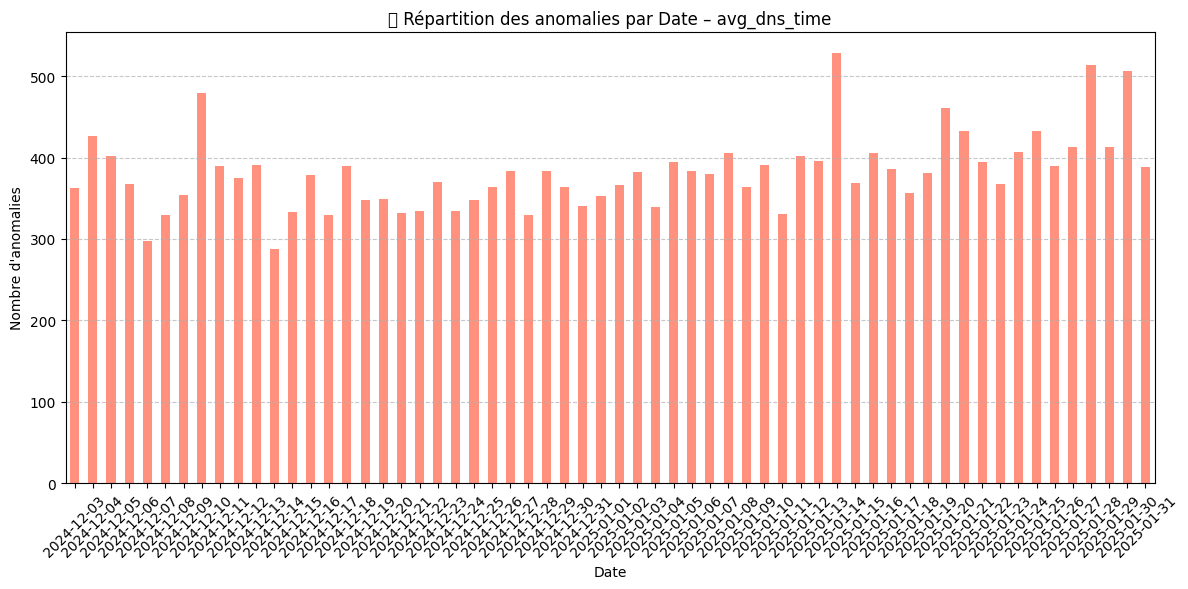


🔍 [ avg_latence_scoring ]
🔴 Nombre total de jumps détectés : 24562
📊 Proportion de jumps par OLT : 4.64
📊 Proportion de jumps par jours : 409.37


<ipython-input-456-ffe1454668f4>:34: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


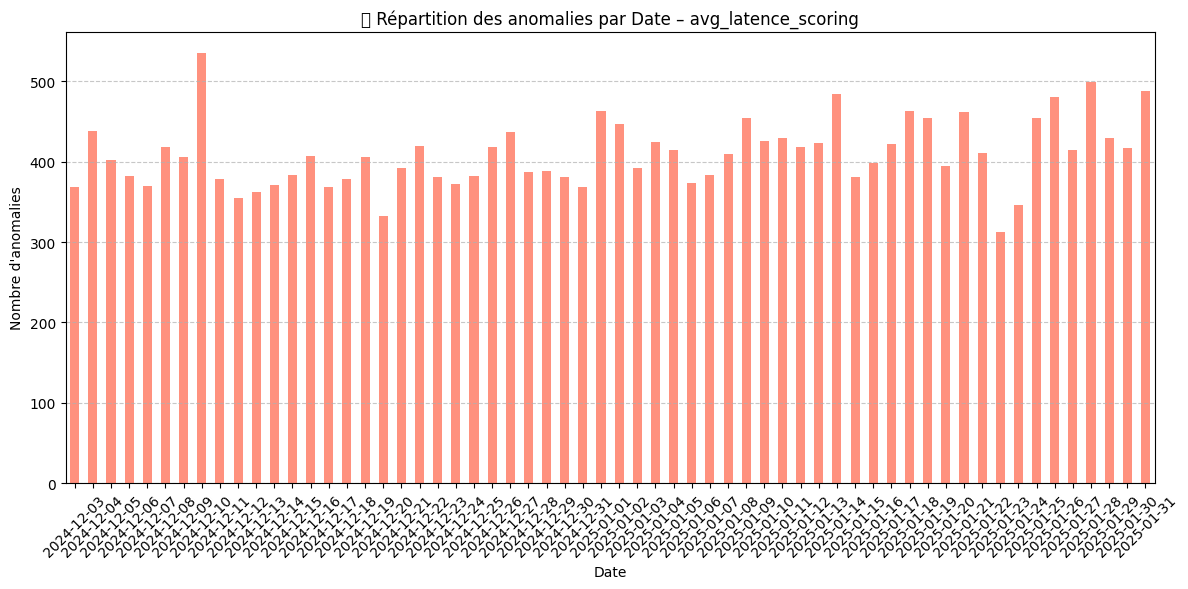


🔍 [ avg_score_scoring ]
🔴 Nombre total de jumps détectés : 20901
📊 Proportion de jumps par OLT : 3.95
📊 Proportion de jumps par jours : 348.35


<ipython-input-456-ffe1454668f4>:34: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


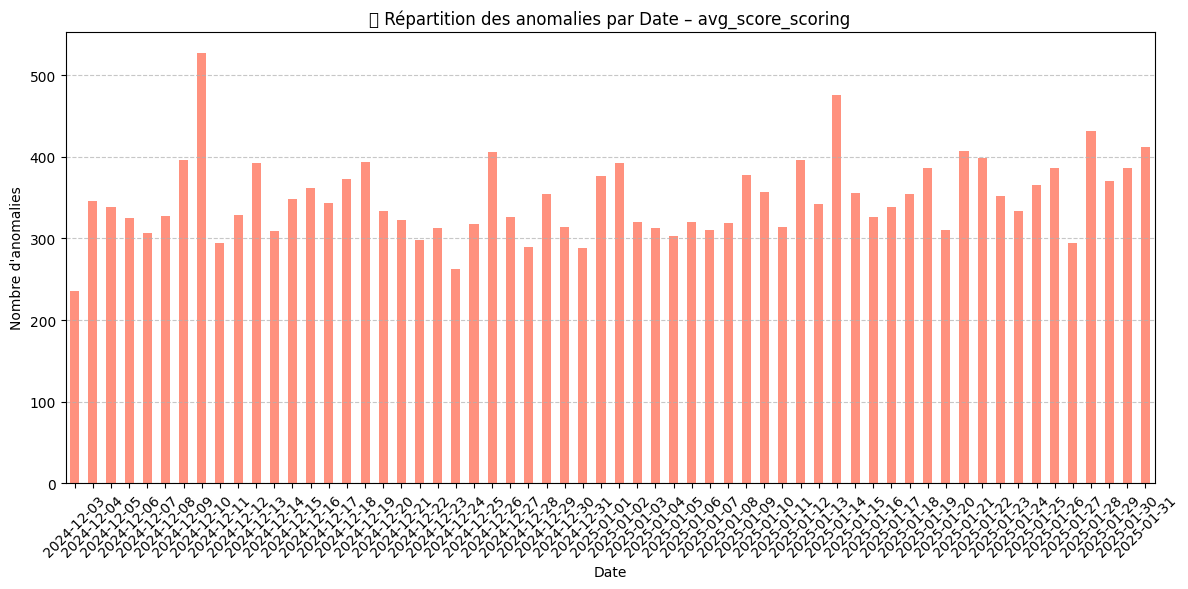

In [456]:
import matplotlib.pyplot as plt

# Liste des métriques testées
tests = ["avg_dns_time", "avg_latence_scoring", "avg_score_scoring"]

# Itérer sur chaque test
for test in tests:
    jump_col = f"is_jump_{test}"

    # 1. Nombre total de jumps détectés
    total_jumps = df_jumps_final[jump_col].sum()
    print(f"\n🔍 [ {test} ]")
    print(f"🔴 Nombre total de jumps détectés : {total_jumps}")

    # 2. Proportion par OLT
    jump_ratio = total_jumps / len(olt_list)
    print(f"📊 Proportion de jumps par OLT : {jump_ratio:.2f}")

    # 3. Proportion par jour (ajuster 60 si nécessaire)
    jump_ratio_par_j = total_jumps / 60
    print(f"📊 Proportion de jumps par jours : {jump_ratio_par_j:.2f}")

    # 4. Répartition des dates
    jump_dates = df_jumps_final[df_jumps_final[jump_col]]["date_hour"].dt.date.value_counts().sort_index()

    # 5. Affichage
    plt.figure(figsize=(12, 6))
    jump_dates.plot(kind="bar", color="tomato", alpha=0.7)
    plt.xlabel("Date")
    plt.ylabel("Nombre d'anomalies")
    plt.title(f"📅 Répartition des anomalies par Date – {test}")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


In [457]:
df_jumps_final[df_jumps_final["is_jump_avg_dns_time"]==1].head()

,olt_name,date_hour,code_departement,olt_model,peag_nro,boucle,dsp,pop_dns,nb_test_dns,avg_dns_time,...,type_boucle,type_olt_model,encodage_heure_sin,encodage_heure_cos,encodage_jour_semaine_sin,encodage_jour_semaine_cos,week_end,is_jump_avg_dns_time,is_jump_avg_latence_scoring,is_jump_avg_score_scoring
19,95_olt_5606,2024-12-03 20:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,113,4.577369,...,BU,old,-0.866025,0.500000,0.781831,0.623490,False,True,False,False
248,95_olt_5606,2024-12-13 09:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,98,5.164171,...,BU,old,0.707107,-0.707107,-0.433884,-0.900969,False,True,False,False
346,95_olt_5606,2024-12-17 11:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,71,5.926437,...,BU,old,0.258819,-0.965926,0.781831,0.623490,False,True,False,False
438,95_olt_5606,2024-12-21 07:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,222,5.132649,...,BU,old,0.965926,-0.258819,-0.974928,-0.222521,True,True,False,False
517,95_olt_5606,2024-12-24 14:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,109,5.084553,...,BU,old,-0.500000,-0.866025,0.781831,0.623490,False,True,False,False


In [458]:
group_vars = ['type_boucle', 'type_olt_model', 'week_end']
metrics = ["avg_dns_time", "avg_latence_scoring", "avg_score_scoring"]

# Itérer sur chaque métrique de jump
for metrique in metrics:
    jump_col = f"is_jump_{metrique}"

    # Créer le résumé groupé
    df_summary = df_jumps_final[group_vars + [jump_col]].groupby(group_vars).agg(
        total=(jump_col, 'count'),
        jumps=(jump_col, 'sum')
    ).reset_index()

    # Calcul du taux de jump
    df_summary["jump_rate"] = df_summary["jumps"] / df_summary["total"]

    # Affichage (ou export)
    print(f"\n📊 Résumé des jumps pour : {metrique}")
    print(df_summary)



📊 Résumé des jumps pour : avg_dns_time
  type_boucle type_olt_model  week_end    total  jumps  jump_rate
0          BU            New     False  1524731   9936   0.006517
1          BU            New      True   557692   3268   0.005860
2          BU            old     False   337112   2061   0.006114
3          BU            old      True   123002    640   0.005203
4        FTTH            New     False   849386   5181   0.006100
5        FTTH            New      True   310822   1721   0.005537
6        FTTH            old     False    10172     73   0.007177
7        FTTH            old      True     3667     22   0.005999

📊 Résumé des jumps pour : avg_latence_scoring
  type_boucle type_olt_model  week_end    total  jumps  jump_rate
0          BU            New     False  1524731  10352   0.006789
1          BU            New      True   557692   3846   0.006896
2          BU            old     False   337112   1664   0.004936
3          BU            old      True   123002    629 

Ouput :
Tableau en fonction seuil le nombre de jump détecté

Lister les avantages du jump : indépendant du modèle, région etc.. on prends en compte spécifité du réseau

Abre séparant le total des jump en fonction du modèle, région et date clés

# Modéliser l'apparition des jumps DNS avec le processus de Hawkes Non retenu et impossible sur collab d'avoir tick

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tick.hawkes import HawkesExpKern

# Charger les données (on suppose que df_jumps_final contient les jumps détectés)
df_jumps = df_jumps_final[df_jumps_final["is_jump"]]  # Garder uniquement les jumps
df_jumps = df_jumps.sort_values("date_hour")  # Trier par date

# Convertir les timestamps en format numérique (secondes depuis le début)
t_start = df_jumps["date_hour"].min()
timestamps = (df_jumps["date_hour"] - t_start).dt.total_seconds().values

# Préparer les timestamps sous forme de liste (format pour tick)
timestamps_list = [timestamps]

# Initialiser et ajuster le modèle de Hawkes avec un noyau exponentiel
hawkes = HawkesExpKern(decay=0.1)  # decay définit la décroissance de l'excitation
hawkes.fit(timestamps_list)

# Récupérer les paramètres estimés
mu_est, alpha_est = hawkes.baseline[0], hawkes.adjacency[0, 0]

# Afficher les résultats
print(f"📊 Intensité de base (μ) : {mu_est:.4f}")
print(f"🔥 Auto-excitation (α) : {alpha_est:.4f}")

# Visualisation des timestamps et intensité du processus
plt.figure(figsize=(12, 5))
plt.hist(timestamps, bins=50, color="blue", alpha=0.7, label="Jumps détectés")
plt.xlabel("Temps (secondes depuis début)")
plt.ylabel("Nombre de jumps")
plt.title("📈 Répartition des Jumps DNS dans le temps")
plt.legend()
plt.grid()
plt.show()


<ipython-input-299-6e62c0949c4f>:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_jumps["date"] = df_jumps["date_hour"].dt.floor("H")  # Regrouper à l’heure
<ipython-input-299-6e62c0949c4f>:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(df_jumps["date"].min(), df_jumps["date"].max(), freq="H")


<Figure size 1200x500 with 0 Axes>

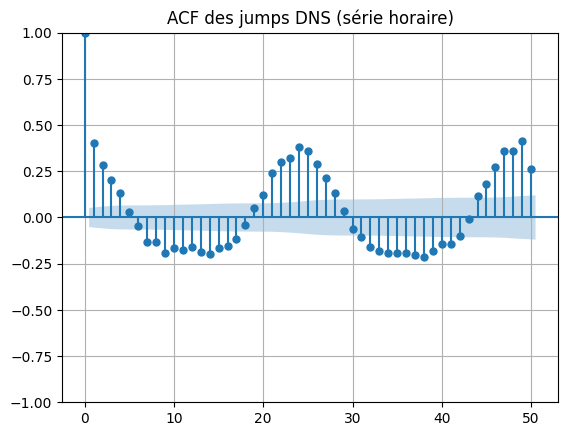

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# --- Étape 1 : série binaire des jumps par heure/jour ---

# On suppose que df_jumps_final existe déjà
df_jumps = df_jumps_final[df_jumps_final["is_jump"]].copy()
df_jumps["date"] = df_jumps["date_hour"].dt.floor("H")  # Regrouper à l’heure

# Créer une série temporelle binaire : 1 si jump, 0 sinon
time_range = pd.date_range(df_jumps["date"].min(), df_jumps["date"].max(), freq="H")
jump_series = pd.Series(0, index=time_range)
jump_counts = df_jumps["date"].value_counts()
jump_series[jump_counts.index] = jump_counts.values

# --- Étape 2 : ACF (autocorrelation) ---

plt.figure(figsize=(12, 5))
plot_acf(jump_series, lags=50, title="ACF des jumps DNS (série horaire)")
plt.grid()
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


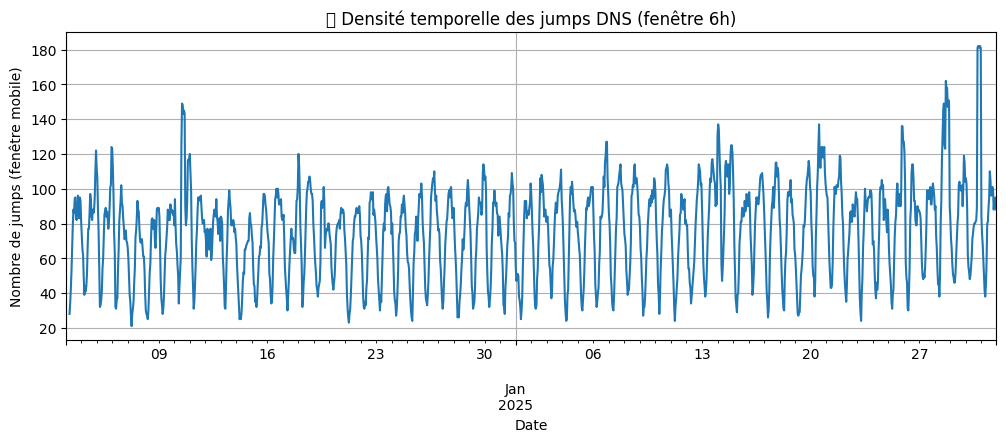

In [ ]:
plt.figure(figsize=(12, 4))
jump_series.rolling(window=6).sum().plot()
plt.title("🔍 Densité temporelle des jumps DNS (fenêtre 6h)")
plt.xlabel("Date")
plt.ylabel("Nombre de jumps (fenêtre mobile)")
plt.grid()
plt.show()


# Jump utilisant la théorie des valeurs extrêmes (Andersen et Al.) NON RETENU

In [ ]:
def detect_jumps_evt(df, window=2, lambda_quantile=0.999):
    df = df.copy()
    df["log_dns"] = np.log(df["avg_dns_time"])  # Transformation log pour éviter les effets de scale
    df["diff_log"] = df["log_dns"].diff()  # Différence log pour capturer les variations relatives

    # Estimation de la volatilité locale
    df["volatility"] = df["diff_log"].rolling(window=window, min_periods=1).std()

    # Calcul de la statistique de test normalisée
    df["stat_jump"] = df["diff_log"].abs() / df["volatility"]

    # Extraction des valeurs extrêmes pour la modélisation EVT
    extreme_values = df["stat_jump"].dropna()
    threshold = np.percentile(extreme_values, 95)  # Seuil initial pour EVT (top 5%)

    # Ajustement de la Generalized Pareto Distribution (GPD)
    params = genpareto.fit(extreme_values[extreme_values > threshold])
    xi, mu, sigma = params

    # Calcul du seuil EVT
    evt_threshold = mu + (sigma / xi) * ((1 / (1 - lambda_quantile)) ** (-xi) - 1)

    # Détection des jumps
    df["is_jump"] = df["stat_jump"] > evt_threshold

    return df, evt_threshold

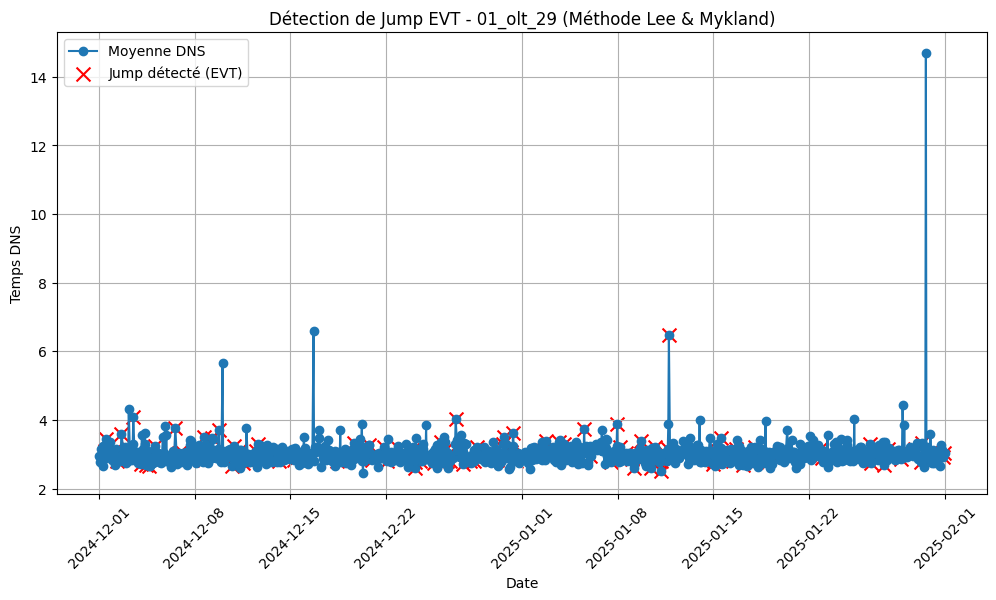

🔴 Seuil EVT calculé : 2.24
📊 Nombre total de jumps détectés : 140


In [ ]:
olt_name = "01_olt_29"  # Remplace par l'OLT souhaité
df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name].sort_values("date_hour")

# Appliquer la détection EVT
df_jumps, evt_threshold = detect_jumps_evt(df_olt)

# Tracer les résultats
plt.figure(figsize=(12, 6))
plt.plot(df_olt["date_hour"], df_olt["avg_dns_time"], label="Moyenne DNS", marker="o", linestyle="-")
plt.scatter(df_jumps[df_jumps["is_jump"]]["date_hour"], df_jumps[df_jumps["is_jump"]]["avg_dns_time"],
            color="red", label="Jump détecté (EVT)", marker="x", s=100)
plt.xlabel("Date")
plt.ylabel("Temps DNS")
plt.title(f"Détection de Jump EVT - {olt_name} (Méthode Lee & Mykland)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Affichage du seuil EVT et nombre de jumps détectés
print(f"🔴 Seuil EVT calculé : {evt_threshold:.2f}")
print(f"📊 Nombre total de jumps détectés : {df_jumps['is_jump'].sum()}")